# Task 2: Multi-Modal Cardiac Image Fusion



**Scenario:** CT shows sharp structural boundaries; MRI shows soft-tissue variation far better. This notebook mathematically fuses one CT slice with its perfectly aligned MRI counterpart into a single matrix that carries both strengths.



**Data note:** the downloaded 'Heart CT & MRI Dataset' (`CV_DataSets/CT and MRI Fusion/synthetic_slices/`) turned out to contain only flat, two-value placeholder disks with no internal texture — equalization, thresholding, and fusion on them would be visually meaningless. Instead, `data/ct_slice.png` is a real, detailed CT slice (from the DICOM-derived series), and `data/mri_slice.png` is a **pixel-aligned simulated MRI-style companion** derived from that same slice (bone/soft-tissue contrast inverted and softened to mimic T1-weighted appearance — see `Lab 02/Task_2_Cardiac_Fusion/readme.md` for the exact simulation steps). This keeps the two inputs perfectly corresponding while giving the fusion pipeline real anatomical structure to work with.

In [1]:
import cv2

import numpy as np

import matplotlib.pyplot as plt

import os



CT_PATH = 'data/ct_slice.png'

MRI_PATH = 'data/mri_slice.png'

OUTPUT_DIR = 'output'

os.makedirs(OUTPUT_DIR, exist_ok=True)

## 1. Load Modalities

Load the CT slice and its corresponding MRI-style slice as single-channel matrices of identical shape.

Slice shape: (512, 512)


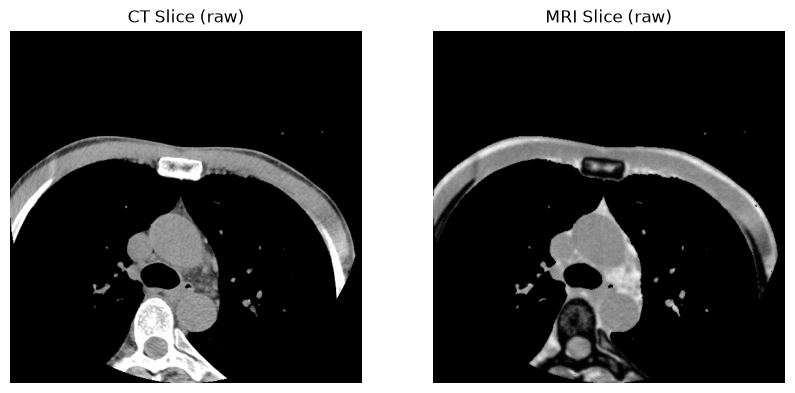

In [2]:
ct = cv2.imread(CT_PATH, cv2.IMREAD_GRAYSCALE)

mri = cv2.imread(MRI_PATH, cv2.IMREAD_GRAYSCALE)

assert ct is not None and mri is not None, 'Could not load one of the modalities'

assert ct.shape == mri.shape, 'CT and MRI slices must be pixel-aligned'

print('Slice shape:', ct.shape)



fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(ct, cmap='gray')

axes[0].set_title('CT Slice (raw)')

axes[0].axis('off')

axes[1].imshow(mri, cmap='gray')

axes[1].set_title('MRI Slice (raw)')

axes[1].axis('off')

plt.savefig(f'{OUTPUT_DIR}/01_raw_modalities.png', bbox_inches='tight')

plt.show()

## 2. Histogram Equalization

Equalize each modality independently before blending, so both contribute their full dynamic range to the fusion.

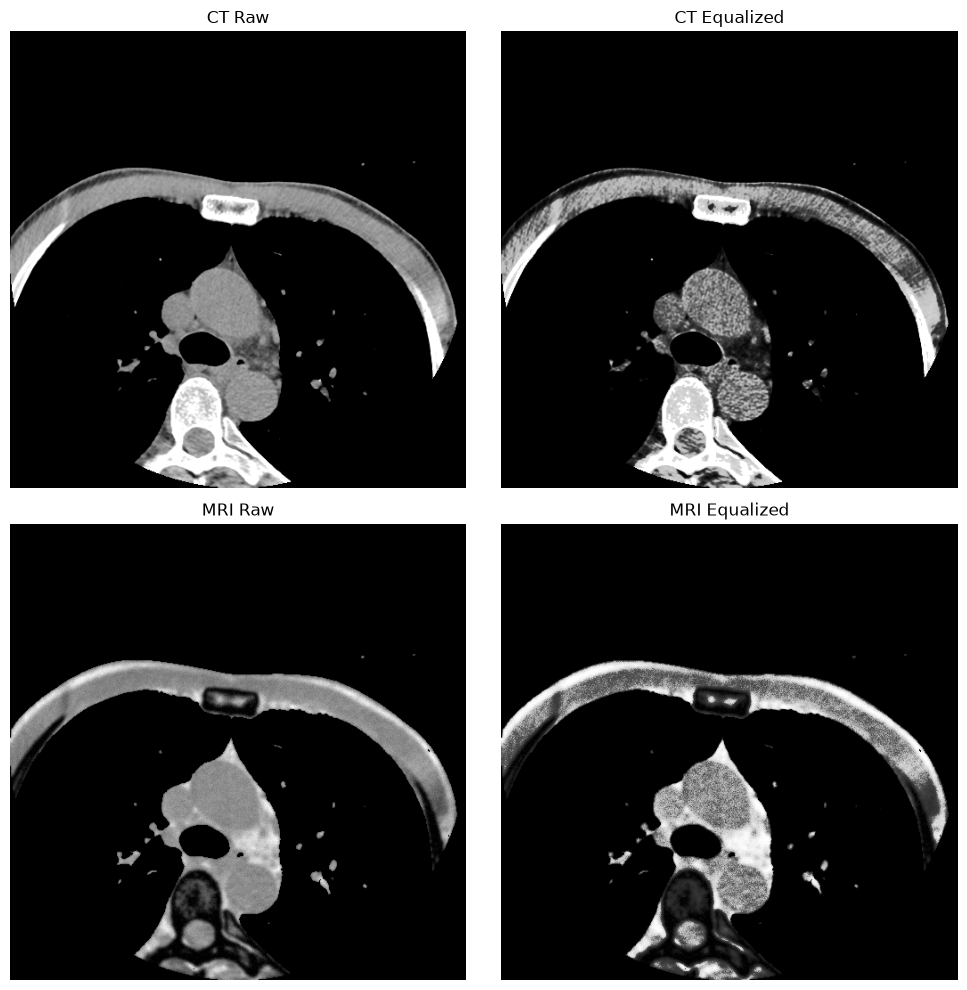

In [3]:
ct_eq = cv2.equalizeHist(ct)

mri_eq = cv2.equalizeHist(mri)



fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0, 0].imshow(ct, cmap='gray'); axes[0, 0].set_title('CT Raw'); axes[0, 0].axis('off')

axes[0, 1].imshow(ct_eq, cmap='gray'); axes[0, 1].set_title('CT Equalized'); axes[0, 1].axis('off')

axes[1, 0].imshow(mri, cmap='gray'); axes[1, 0].set_title('MRI Raw'); axes[1, 0].axis('off')

axes[1, 1].imshow(mri_eq, cmap='gray'); axes[1, 1].set_title('MRI Equalized'); axes[1, 1].axis('off')

plt.tight_layout()

plt.savefig(f'{OUTPUT_DIR}/02_equalization.png', bbox_inches='tight')

plt.show()

## 3. Color Mapping

CT is mapped through `COLORMAP_BONE` to emphasize its structural edges; MRI is mapped through `COLORMAP_JET` so its soft-tissue intensity variation stands out.

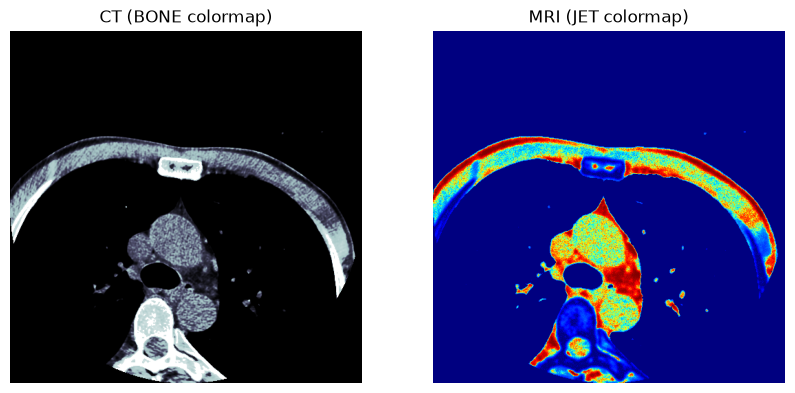

In [4]:
ct_color = cv2.applyColorMap(ct_eq, cv2.COLORMAP_BONE)

mri_color = cv2.applyColorMap(mri_eq, cv2.COLORMAP_JET)



fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(cv2.cvtColor(ct_color, cv2.COLOR_BGR2RGB)); axes[0].set_title('CT (BONE colormap)'); axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(mri_color, cv2.COLOR_BGR2RGB)); axes[1].set_title('MRI (JET colormap)'); axes[1].axis('off')

plt.savefig(f'{OUTPUT_DIR}/03_colormaps.png', bbox_inches='tight')

plt.show()

## 4. Multi-Modal Weighted Fusion

`cv2.addWeighted` blends the two colored matrices. CT gets the heavier weight (`alpha=0.7`) to preserve its sharp anatomical edges; MRI contributes a lighter weight (`beta=0.3`) to layer in soft-tissue variation without washing out CT's boundaries.

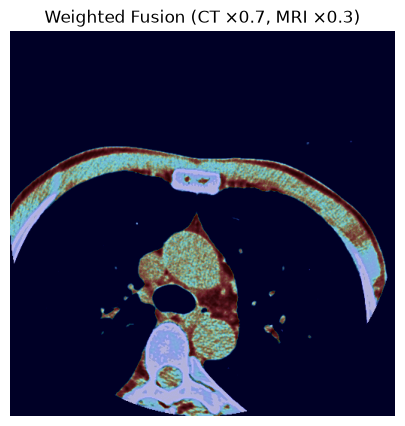

In [5]:
alpha, beta = 0.7, 0.3

fused = cv2.addWeighted(ct_color, alpha, mri_color, beta, 0)



plt.figure(figsize=(5, 5))

plt.imshow(cv2.cvtColor(fused, cv2.COLOR_BGR2RGB))

plt.title(f'Weighted Fusion (CT \u00d7{alpha}, MRI \u00d7{beta})')

plt.axis('off')

plt.savefig(f'{OUTPUT_DIR}/04_weighted_fusion.png', bbox_inches='tight')

plt.show()

## 5. Logarithmic and Power-Law Transformations

Blending two already-bright colored images can crush detail into pure black or blow it out to pure white. A log transform followed by a fractional gamma re-expands the fused matrix's dynamic range so no data is lost at either extreme.

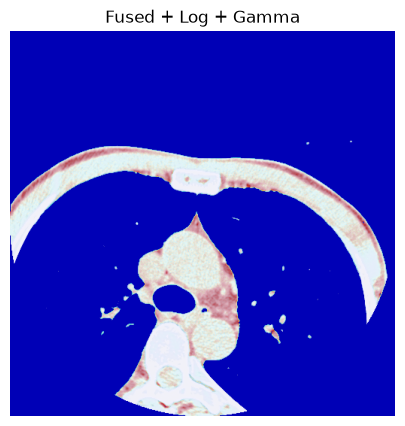

In [6]:
def log_transform(image):

    image_f = image.astype(np.float64)

    c = 255.0 / np.log(1 + image_f.max())

    return np.clip(c * np.log(1 + image_f), 0, 255).astype(np.uint8)





def gamma_transform(image, gamma=0.8):

    normalized = image.astype(np.float64) / 255.0

    return np.clip(255.0 * np.power(normalized, gamma), 0, 255).astype(np.uint8)





fused_log = log_transform(fused)

fused_final = gamma_transform(fused_log, gamma=0.8)



plt.figure(figsize=(5, 5))

plt.imshow(cv2.cvtColor(fused_final, cv2.COLOR_BGR2RGB))

plt.title('Fused + Log + Gamma')

plt.axis('off')

plt.savefig(f'{OUTPUT_DIR}/05_log_gamma_fused.png', bbox_inches='tight')

plt.show()

## 6. Comparative Analysis

Standalone CT, standalone MRI, and the final fused output side-by-side, to visually validate that the fusion preserved CT's structural edges while adding MRI's soft-tissue contrast.

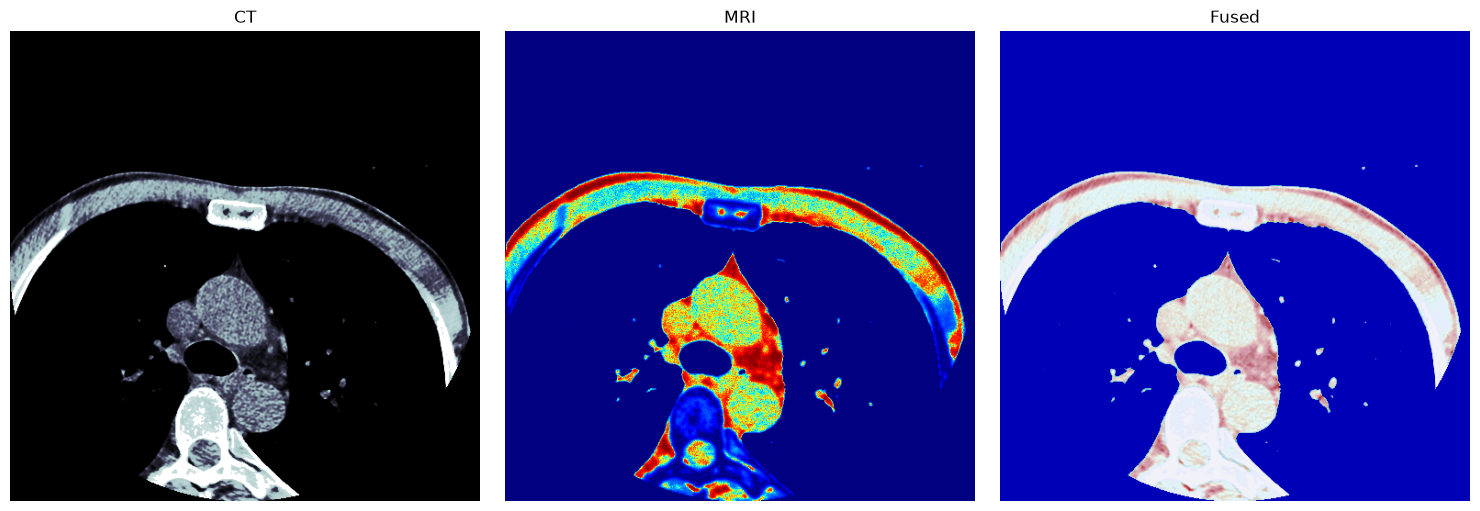

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(cv2.cvtColor(ct_color, cv2.COLOR_BGR2RGB)); axes[0].set_title('CT'); axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(mri_color, cv2.COLOR_BGR2RGB)); axes[1].set_title('MRI'); axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(fused_final, cv2.COLOR_BGR2RGB)); axes[2].set_title('Fused'); axes[2].axis('off')

plt.tight_layout()

plt.savefig(f'{OUTPUT_DIR}/06_comparative_analysis.png', bbox_inches='tight')

plt.show()

## Summary

- Independent equalization gave both modalities full dynamic range before blending.

- `COLORMAP_BONE` on CT keeps structural edges legible; `COLORMAP_JET` on MRI makes soft-tissue variation visually distinct.

- Weighting CT higher (`0.7` vs `0.3`) in `addWeighted` preserves anatomical boundaries while still layering in soft-tissue signal from MRI.

- Log + gamma on the fused result prevented clipping at black/white extremes introduced by the additive blend.